In [134]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [135]:
# Load dataset
df = pd.read_csv("../data/raw/banking_marketing_train.csv'", delimiter=";")
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [137]:
df_encoded = pd.read_csv("../data/processed/banking_marketing_train_processed.csv", delimiter=",")
# from data/preprocess import banking_marketing_train_encoded_eda
# df_encoded = banking_marketing_train_encoded_eda
df_encoded = df_encoded[df.columns.intersection(df_encoded.columns)]

print(df_encoded.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      8       261         1     -1         0         3  0  
1    5      8       151         1     -1         0         3  0  
2    5      8        76         1     -1         0         3  0  
3    5      8        92         1     -1         0         3  0  
4    5      8       198         1     -1         0         3  0  


# Dataset Overview

In [138]:
# Display basic info
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [139]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%   

In [140]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [141]:
# Convert categorical features to category type
categorical_cols = ["job", "marital", "education", "default", "housing", "loan",
                    "contact", "month", "poutcome", "y"]
df[categorical_cols] = df[categorical_cols].astype("category")

# Features By Data Type

## Distribution of numerical features

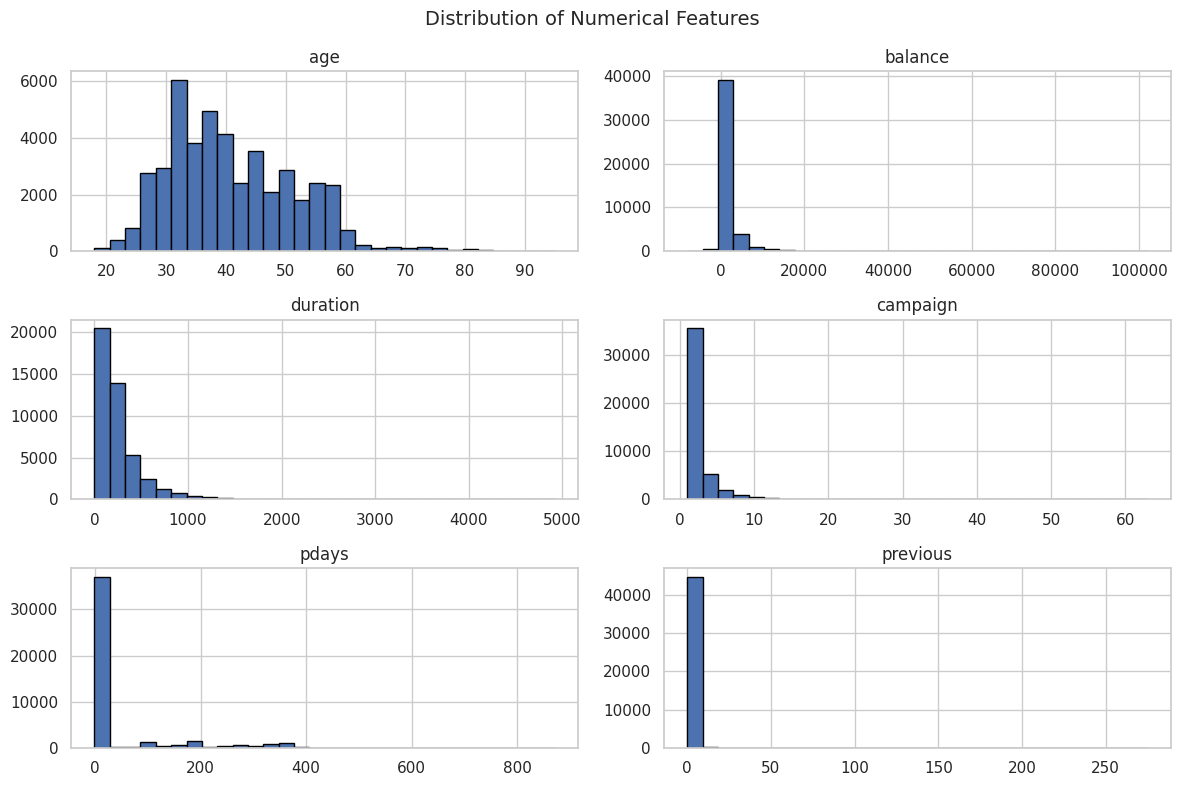

In [142]:
# Distribution of numerical features
num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
df[num_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

## Distribution of categorical features

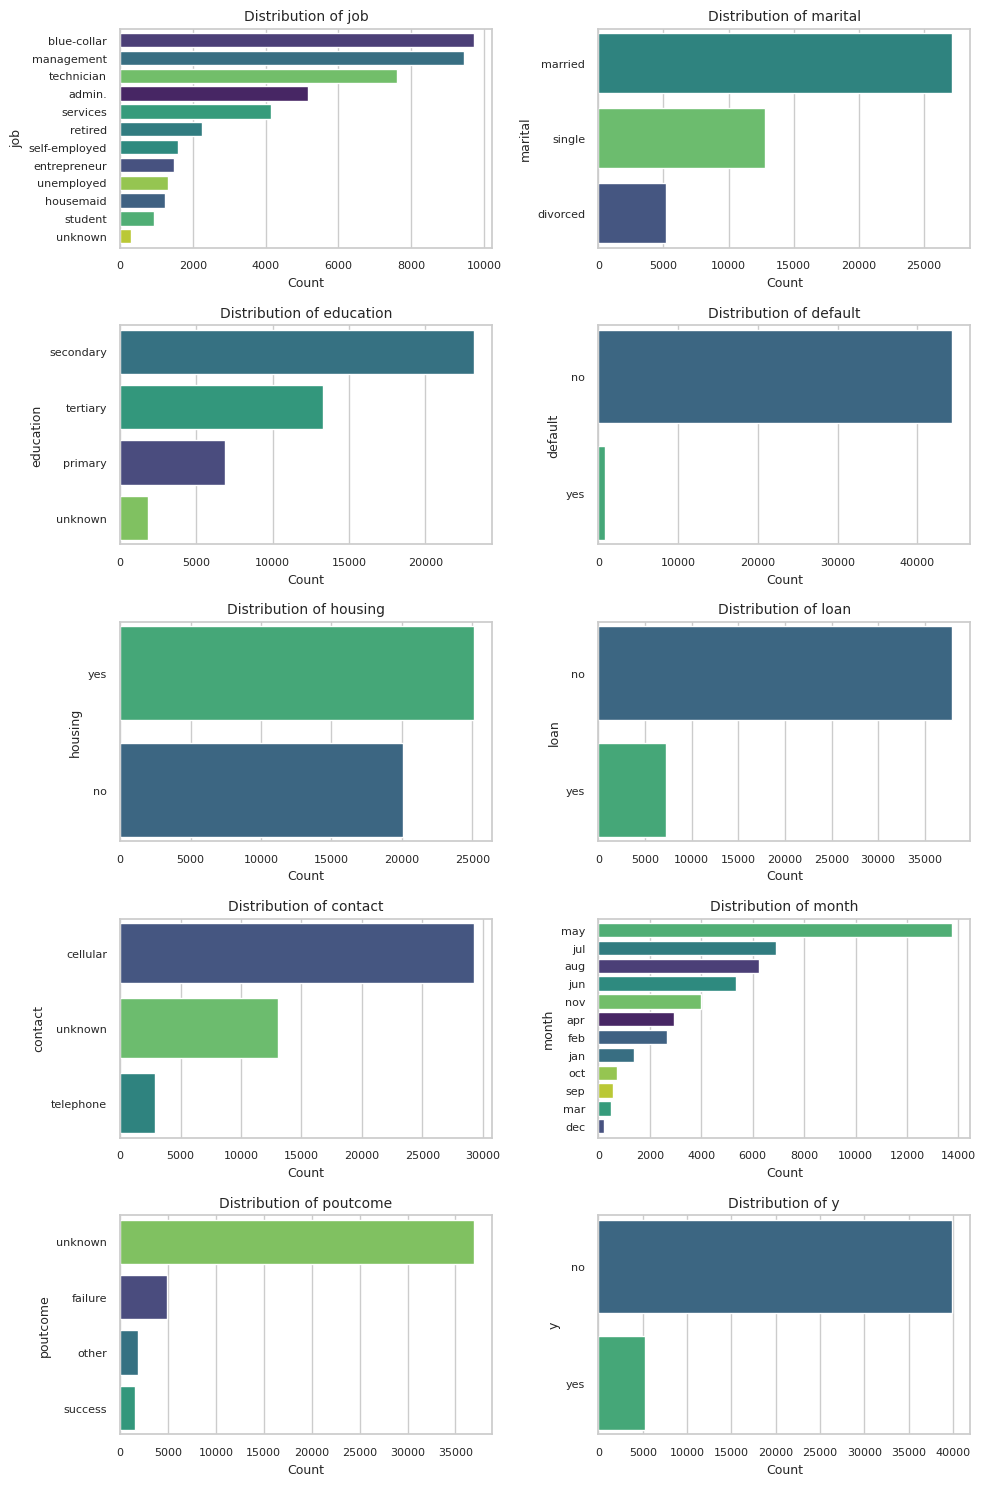

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Set style for better aesthetics
sns.set_style("whitegrid")

# Define number of rows and columns
num_cols = len(categorical_cols)
cols_per_row = 2  # Two plots per row
num_rows = math.ceil(num_cols / cols_per_row)  # Calculate required rows

fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(10, 3 * num_rows))
axes = axes.flatten()  # Flatten to make iteration easier

# Loop through categorical columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index,
        hue=df[col],  # Assign hue to the same variable
        palette="viridis",
        legend=False,  # Hide legend since hue is the same as y
        ax=ax
    )

    ax.set_title(f"Distribution of {col}", fontsize=10)
    ax.set_xlabel("Count", fontsize=9)
    ax.set_ylabel(col, fontsize=9)

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax.margins(y=0.02)  # Reduce whitespace around bars

# Remove empty subplots if num_cols is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1)  # Adjust spacing
plt.show()


# Feature Distribution Analysis

## Campaign Success Rate Distribution

<ipython-input-144-416e73cf623c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["y"], palette=["red", "green"])


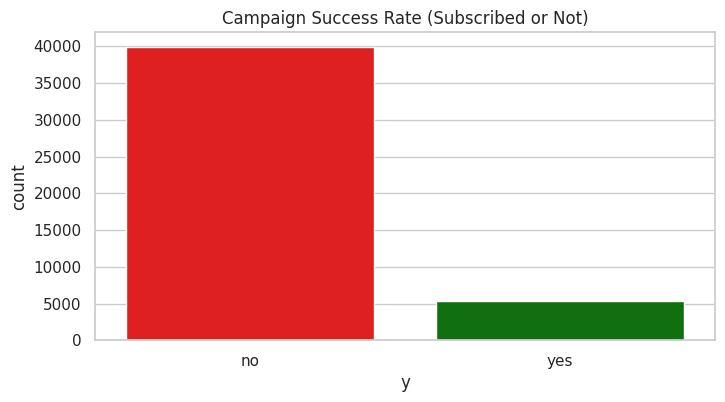

In [144]:
# Campaign Performance Analysis
plt.figure(figsize=(8, 4))
sns.countplot(x=df["y"], palette=["red", "green"])
plt.title("Campaign Success Rate (Subscribed or Not)")
plt.show()

# Correlation Map

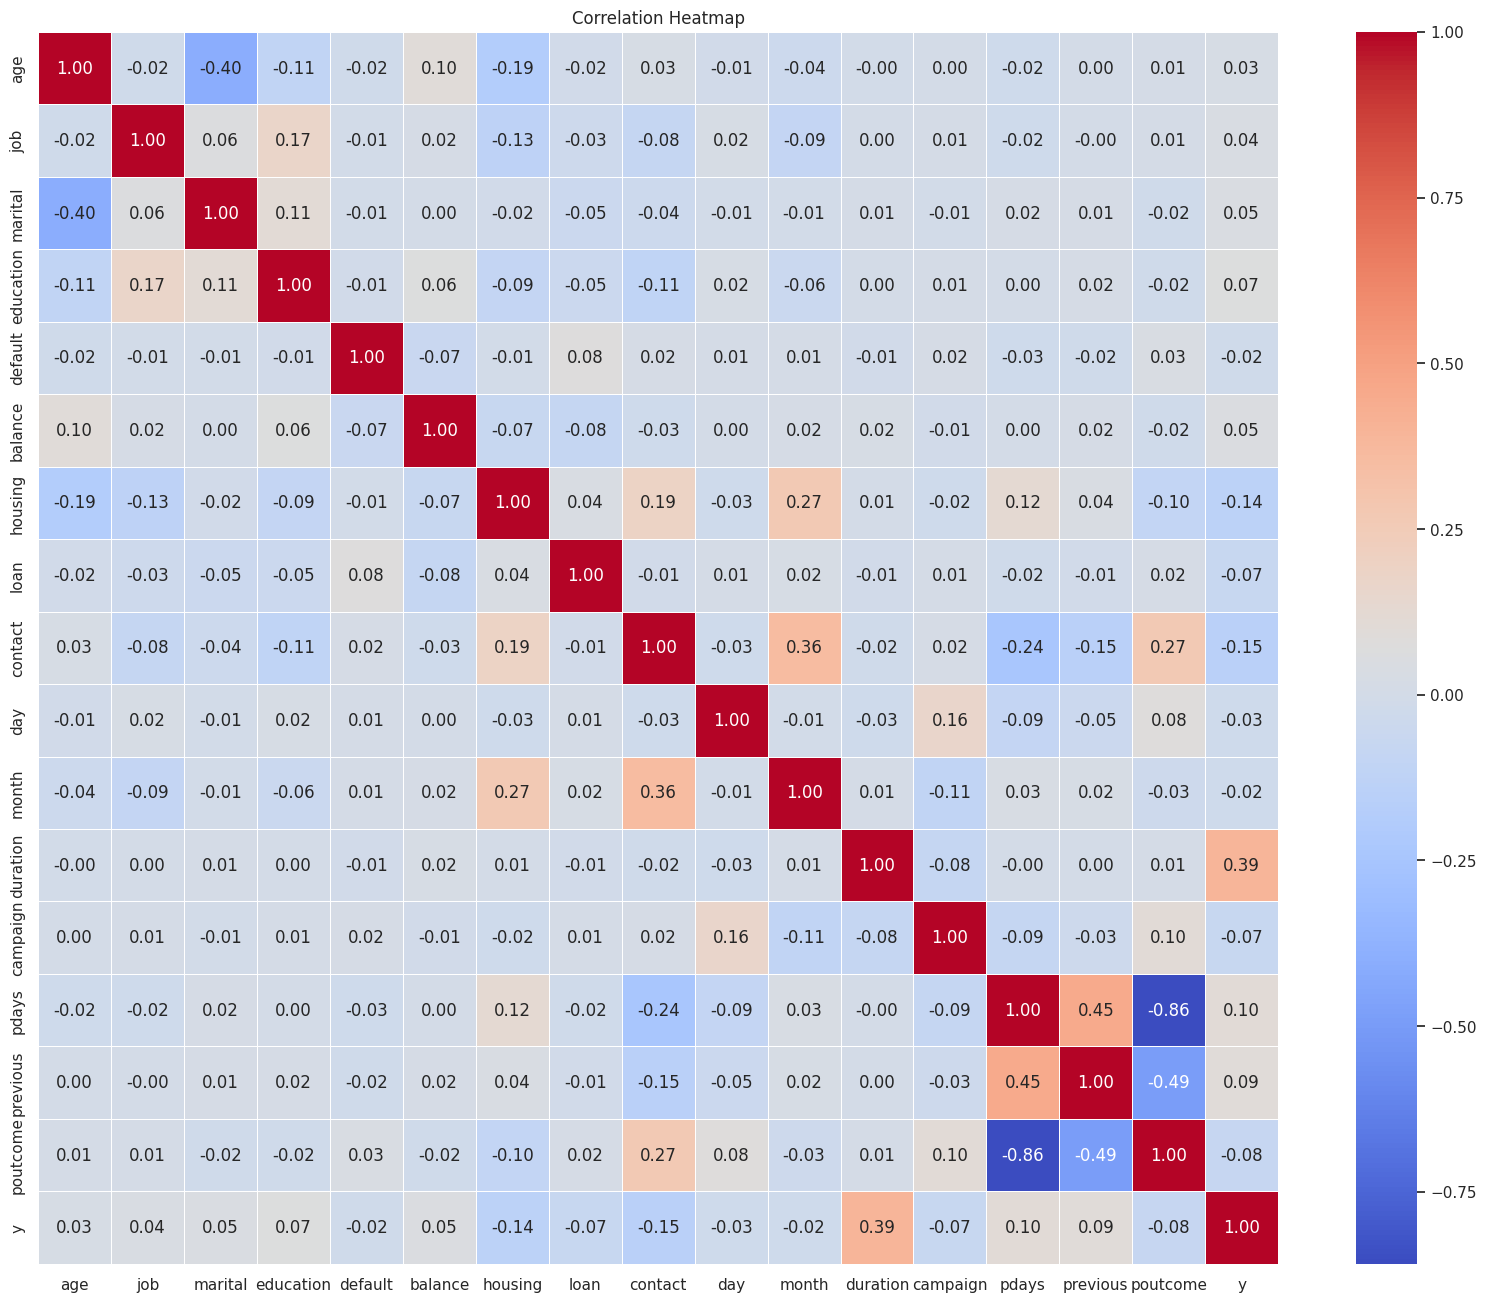

In [145]:
# Compute correlation matrix
# Exclude non-numeric columns before calculating correlation
numeric_df = df_encoded.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Observations:  
Variables with a correlation coefficient >= 0.1 with the target variable y: housing, contact, duration, pdays.

# Bivariate Analysis

Based on observations on the correlation map, we decided to investigate the bivariate relationship between features with high correlation, especially those which are highly correlated to subscription rate(y).

### Contact Duration VS Subscription(y)

<ipython-input-146-eb1db94894ad>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="duration", data=df, palette=["red", "green"])


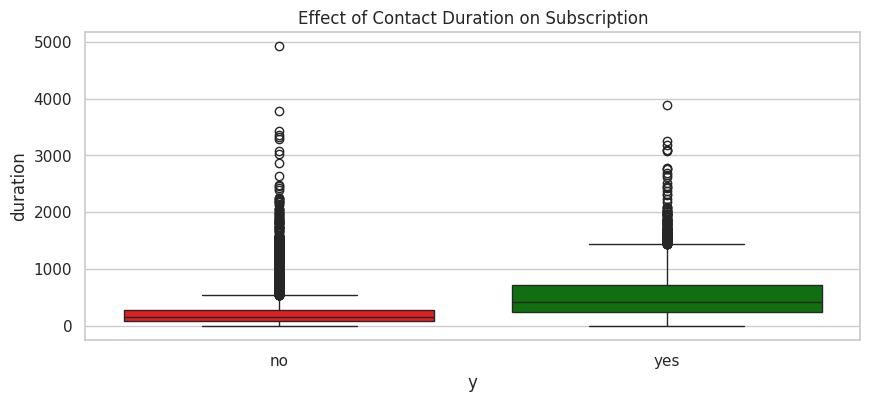

In [146]:
# Effect of Contact Duration on Conversion
plt.figure(figsize=(10, 4))
sns.boxplot(x="y", y="duration", data=df, palette=["red", "green"])
plt.title("Effect of Contact Duration on Subscription")
plt.show()

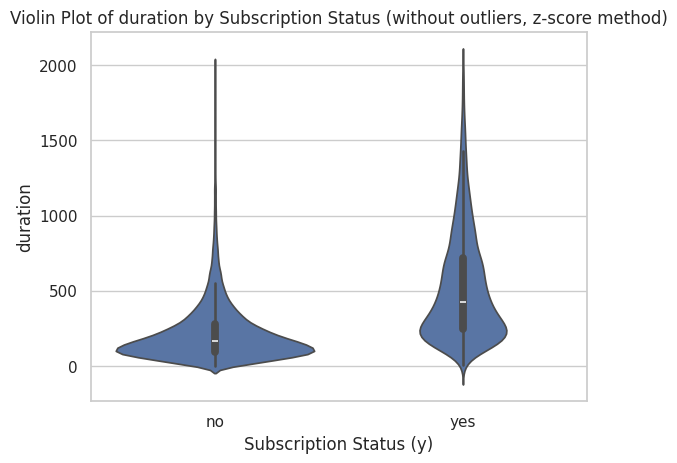

In [147]:
# remove outliers
banking_marketing_train_no_outliers = df[df['duration']<2000]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='duration', data=banking_marketing_train_no_outliers)
plt.title('Violin Plot of duration by Subscription Status (without outliers, z-score method)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('duration')
plt.show()


Observation: smaller duration -> low success rate.

### No. of Contacts(campaign) VS Subscription(y)

<ipython-input-148-490bb3a2ab3e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="campaign", data=df, palette=["red", "green"])


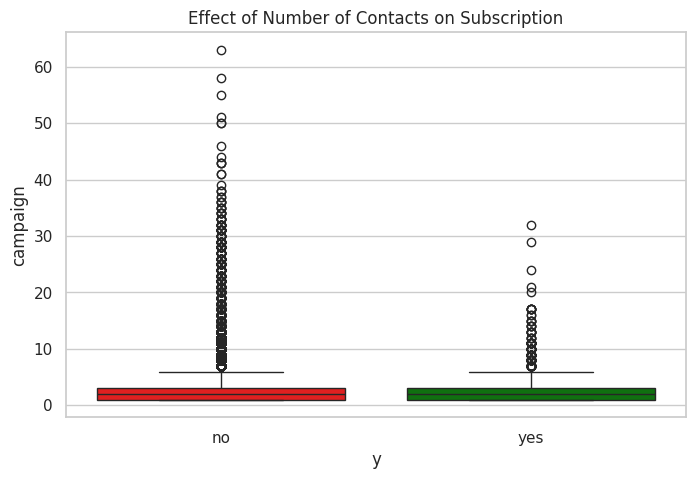

In [148]:
# Number of Contacts vs Subscription Rate
plt.figure(figsize=(8, 5))
sns.boxplot(x="y", y="campaign", data=df, palette=["red", "green"])
plt.title("Effect of Number of Contacts on Subscription")
plt.show()

Observation: There is a negative relationship between the number of contact attempts (campaign) and success rate (y=1), higher number of contacts -> lower success rate.

This suggests that contacting clients too many times may lead to diminishing returns or even campaign fatigue.

### Job Type VS Subscription(y)


<ipython-input-149-16293ebeb9fb>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  job_conversion = df.groupby("job")["y"].value_counts(normalize=True).unstack()


<Figure size 1200x500 with 0 Axes>

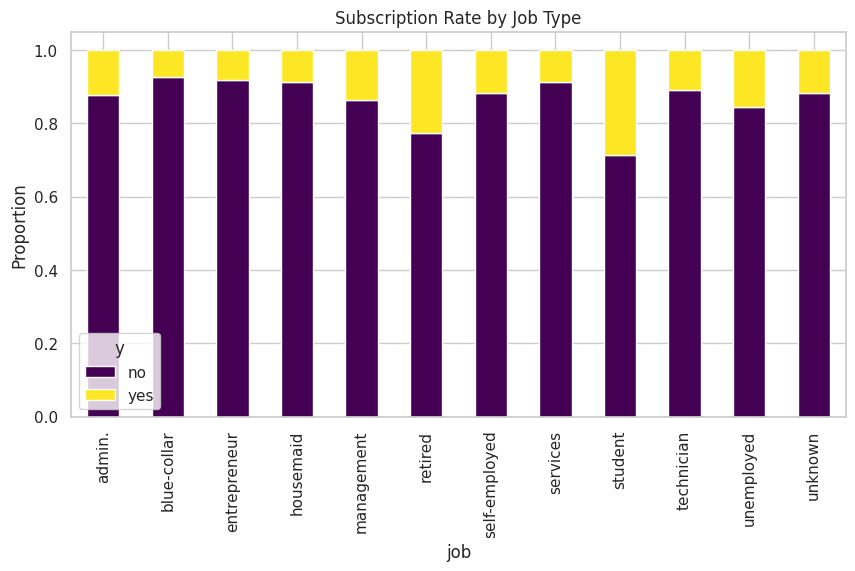

In [149]:
# Success rate per job type
plt.figure(figsize=(12, 5))
job_conversion = df.groupby("job")["y"].value_counts(normalize=True).unstack()
job_conversion.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="viridis")
plt.title("Subscription Rate by Job Type")
plt.ylabel("Proportion")
plt.show()

### Contact Type VS Subscription(y)

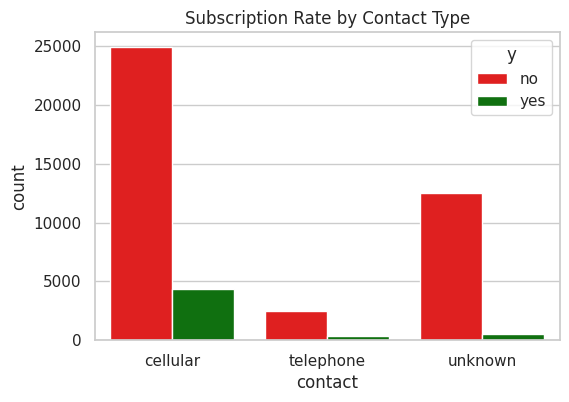

In [150]:
# Subscription Rate by Contact Method
plt.figure(figsize=(6, 4))
sns.countplot(x="contact", hue="y", data=df, palette=["red", "green"])
plt.title("Subscription Rate by Contact Type")
plt.show()

Observation: The conversion rate of cellular > telephone > unknown.

Contact communication type can affect the success rate (y=1) significantly.

### pdays VS Subscription(y)

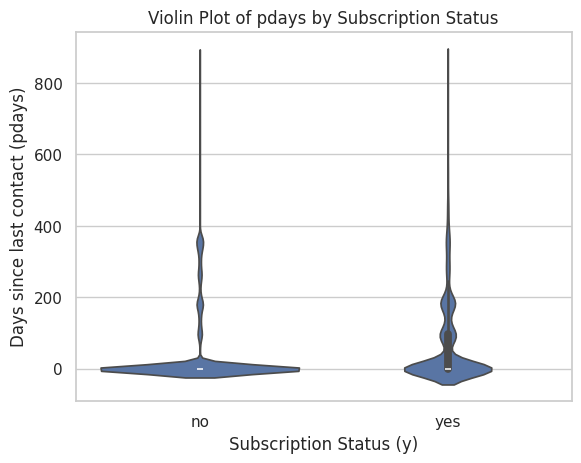

In [151]:
# Violin plot for 'pdays' by Subscription Status
sns.violinplot(x='y', y='pdays', data=df)
plt.title('Violin Plot of pdays by Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Days since last contact (pdays)')
plt.show()

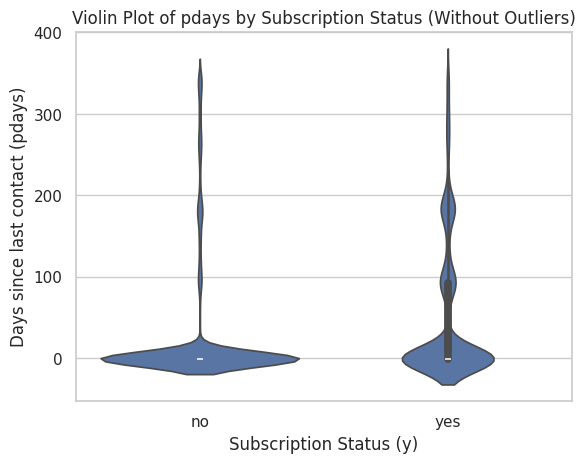

In [152]:
# Remove outliers for 'pdays'
filtered_no_outliers = df[df['pdays'] < 350]
sns.violinplot(x='y', y='pdays', data=filtered_no_outliers)
plt.title('Violin Plot of pdays by Subscription Status (Without Outliers)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Days since last contact (pdays)')
plt.show()

Observation: smaller pdays -> higher succes rate.


## Previous Contact VS Subscription(y)


In [153]:
# Analyze 'previous'
print("\nPrevious Contact Distribution:")
print(df['previous'].value_counts())

filtered_previous = df[df['previous'] != 0]
print("\nSubscription Rate for Non-Zero Previous Contacts:\n", filtered_previous['y'].value_counts())



Previous Contact Distribution:
previous
0      36954
1       2772
2       2106
3       1142
4        714
5        459
6        277
7        205
8        129
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
23         8
20         8
18         6
22         6
24         5
27         5
29         4
21         4
25         4
30         3
26         2
37         2
28         2
38         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: count, dtype: int64

Subscription Rate for Non-Zero Previous Contacts:
 y
no     6352
yes    1905
Name: count, dtype: int64


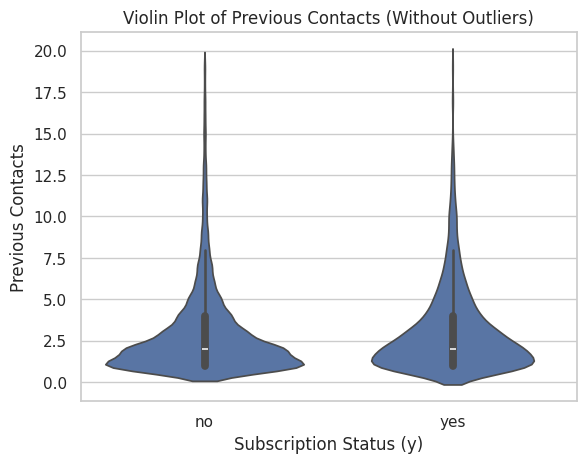

In [154]:
# Remove outliers for 'previous'
filtered_no_outliers = filtered_previous[filtered_previous['previous'] < 20]
sns.violinplot(x='y', y='previous', data=filtered_no_outliers)
plt.title('Violin Plot of Previous Contacts (Without Outliers)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Previous Contacts')
plt.show()

In [155]:
# Mann-Whitney U Test for 'previous'
group0 = df[df['y'] == 0]['previous']
group1 = df[df['y'] == 1]['previous']
stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
print("Mann-Whitney U-Test:")
print("U-statistic:", stat)
print("p-value:", p)

Mann-Whitney U-Test:
U-statistic: nan
p-value: nan


<ipython-input-155-84df6ae59869>:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(group0, group1, alternative='two-sided')


p-value ≈ 3.49e-283, confirming a statistically significant difference between the groups, even though the visual difference appears small.

Observation: Very weak relationship. The overall distribution of previous contacts is similar between subscribed and non-subscribed clients, those who subscribed tend to have slightly higher previous contact counts, suggesting a weak but statistically significant positive association between repeated contact and subscription.

## Housing Loan VS Subscription(y)

In [156]:
# Housing Loan vs Subscription Status
contingency_table = pd.crosstab(df['housing'], df['y'])
print("\nHousing Loan vs Subscription Status Contingency Table:\n", contingency_table)



Housing Loan vs Subscription Status Contingency Table:
 y           no   yes
housing             
no       16727  3354
yes      23195  1935


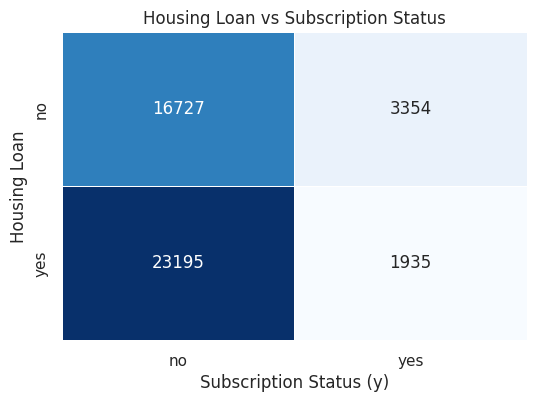

In [157]:
# Heatmap for housing loan vs subscription
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
plt.title('Housing Loan vs Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Housing Loan')
plt.show()

Observation: has housing loan -> low success rate.

## Poutcome VS Previous

<ipython-input-158-1bb811dc18a0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='poutcome', y='previous', data=df, palette="Set2")


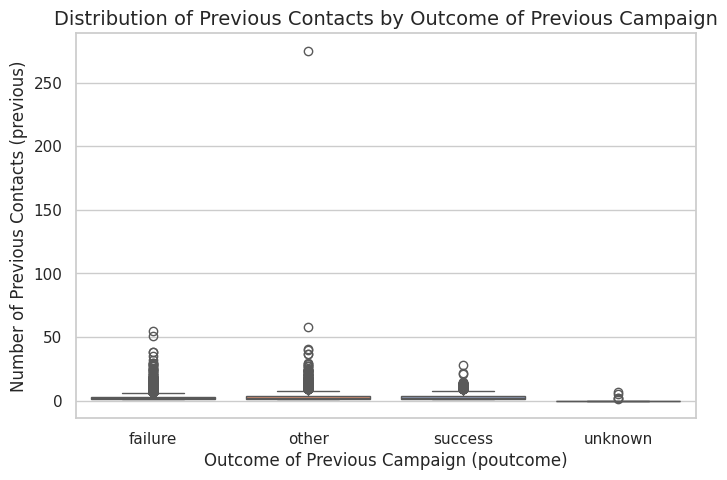

In [158]:
# Set the plot style
sns.set(style="whitegrid")

# Create a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='poutcome', y='previous', data=df, palette="Set2")

# Add title and labels
plt.title("Distribution of Previous Contacts by Outcome of Previous Campaign", fontsize=14)
plt.xlabel("Outcome of Previous Campaign (poutcome)")
plt.ylabel("Number of Previous Contacts (previous)")

# Show the plot
plt.show()

Observations: More tries reduce success rate.

## Poutcome VS Subscription(y)

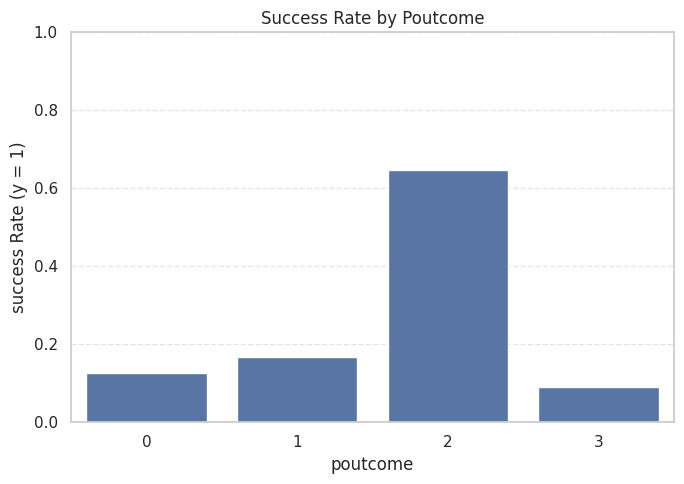

In [159]:
import seaborn as sns

# bar chart: success rate for different poutcome
poutcome_conversion = df_encoded.groupby('poutcome')['y'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=poutcome_conversion, x='poutcome', y='y')
plt.title('Success Rate by Poutcome')
plt.xlabel('poutcome')
plt.ylabel('success Rate (y = 1)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Observation: poutcome = success -> higher success rate (y=1).